<a href="https://colab.research.google.com/github/Keerthana05180/Keerthana05180/blob/main/ML_2_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Churn Prediction (Classification)**

## Problem Statement

Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.
In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features such as:

● Customer Age

● Gender

● Tenure

● Monthly Charges

● Total Charges


● Contract Type

● Payment Method

● Internet Service

● Tech Support

● Online Security

● Customer Support Calls

Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting customer churn.

## Objective

The objective of this task is to:

● Understand and explore the customer dataset

● Perform data preprocessing (missing values, duplicates, outliers)

● Conduct Exploratory Data Analysis (EDA)

● Apply encoding and feature scaling

● Train multiple classification algorithms

● Evaluate models using classification metrics

● Perform cross-validation and hyperparameter tuning

● Select the best-performing model


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE



In [ ]:
df = pd.read_csv("task3_customer_churn_data.csv")

In [ ]:
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.describe())

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
      

In [ ]:
df.isnull().sum()
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

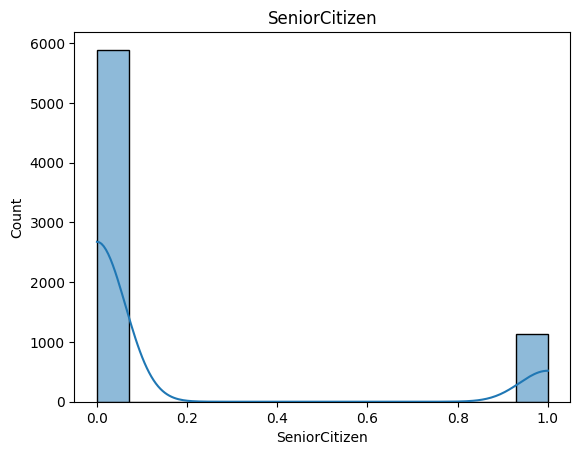

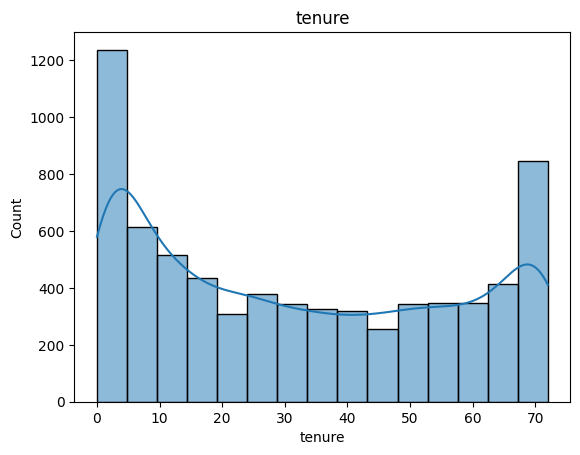

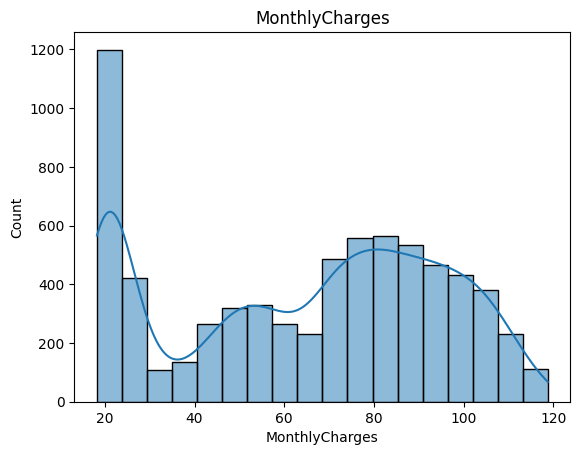

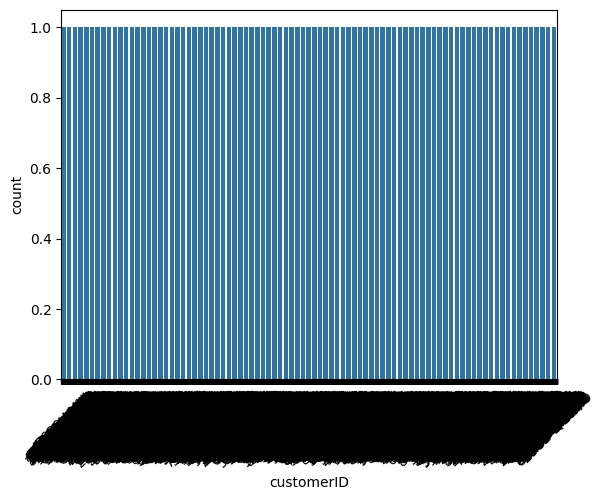

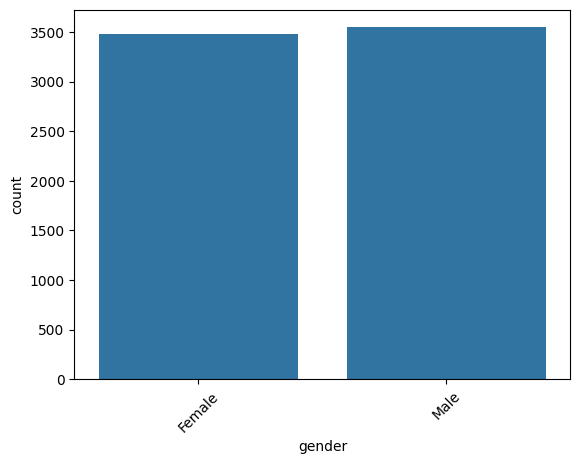

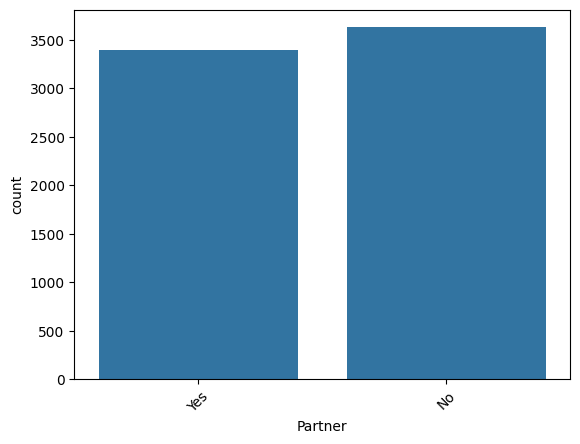

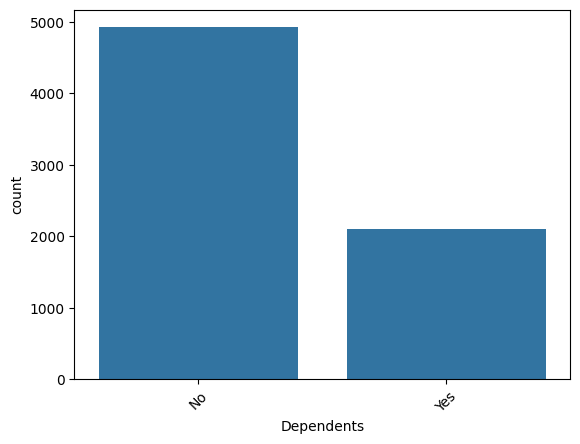

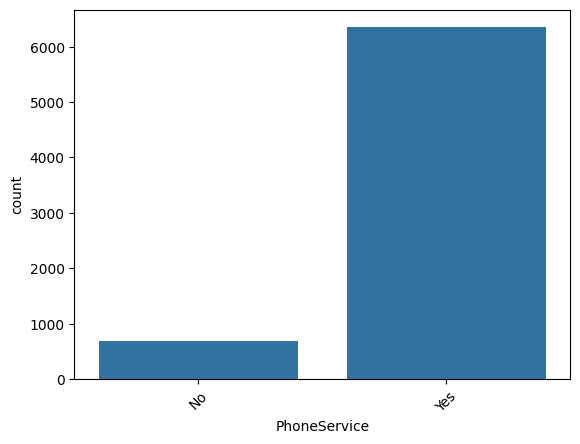

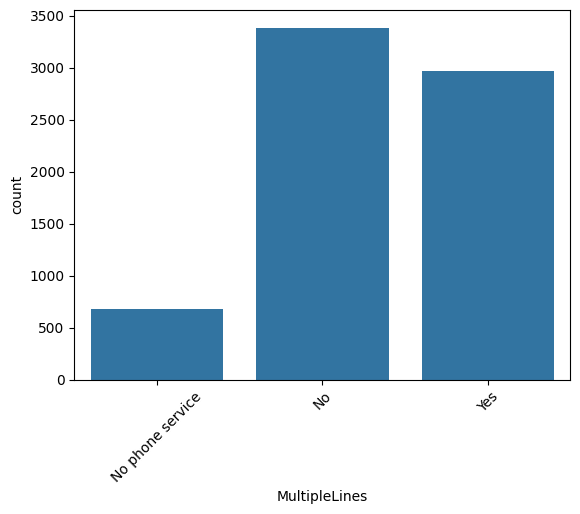

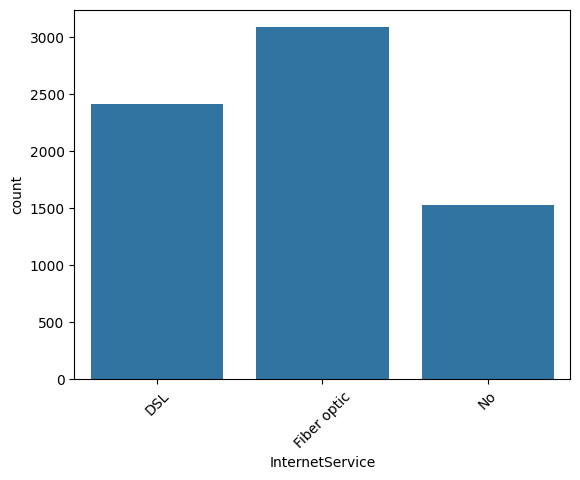

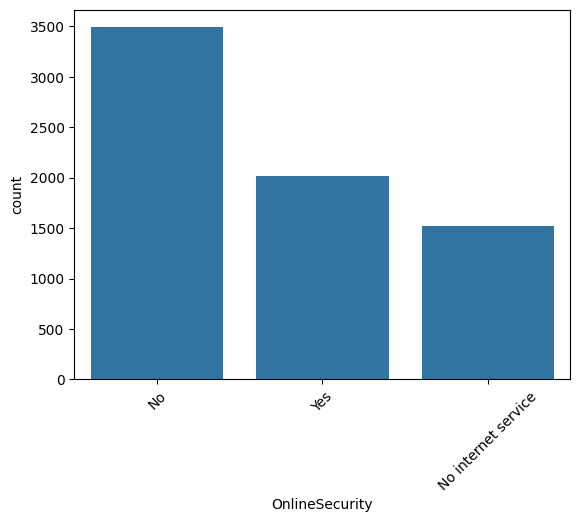

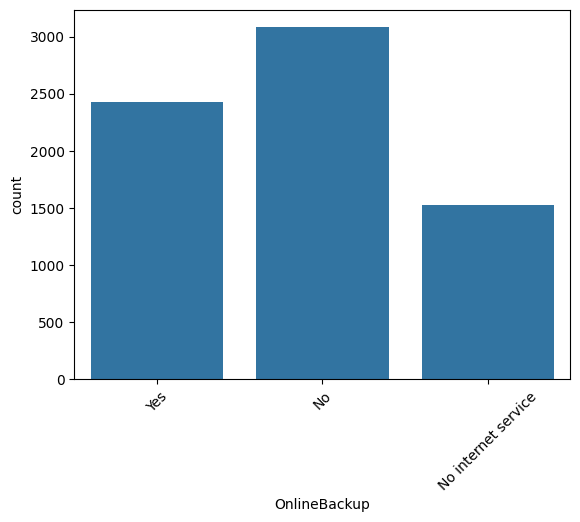

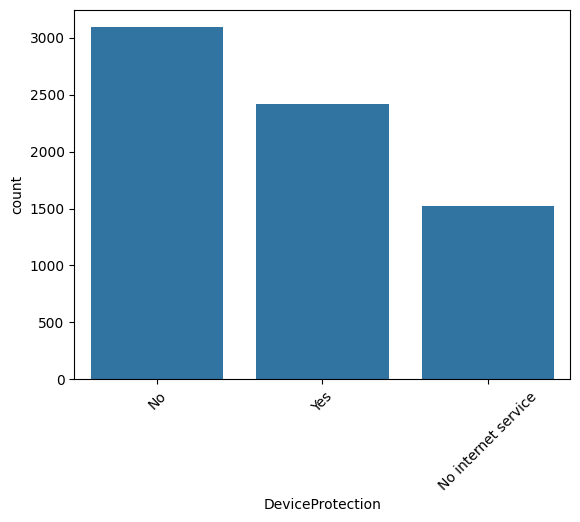

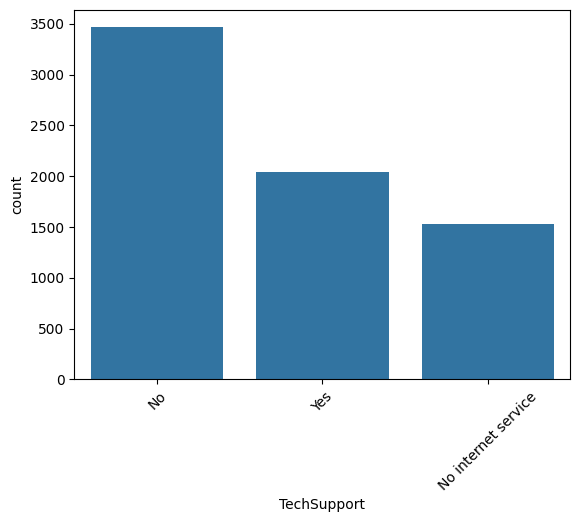

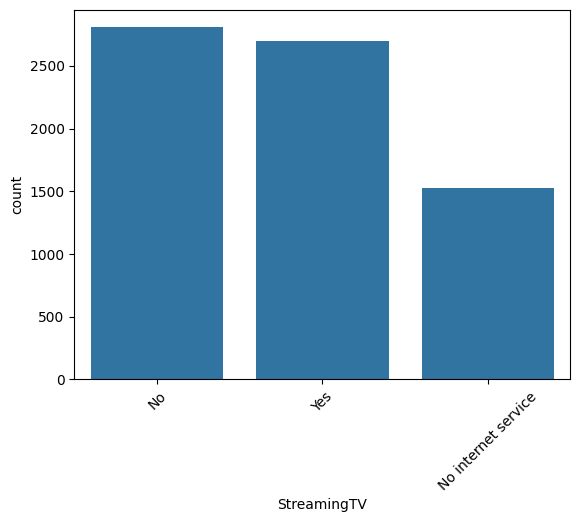

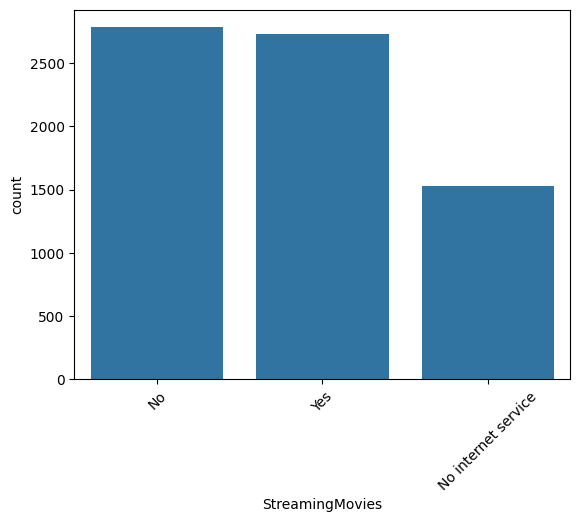

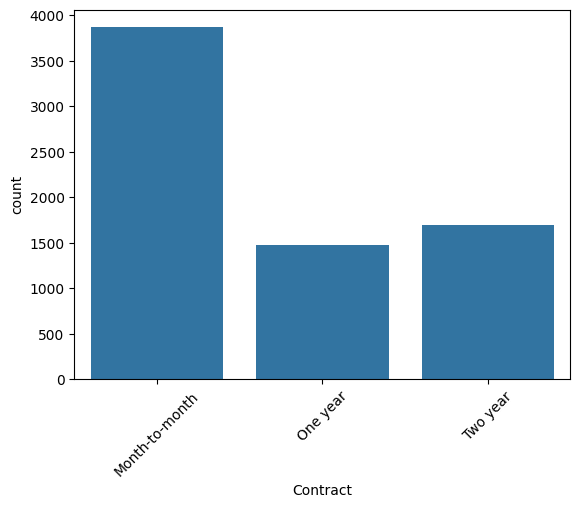

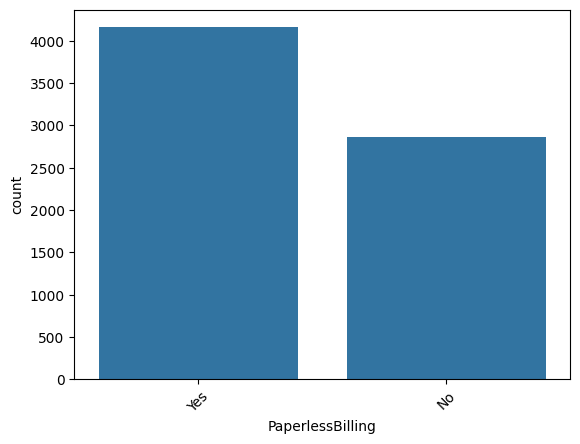

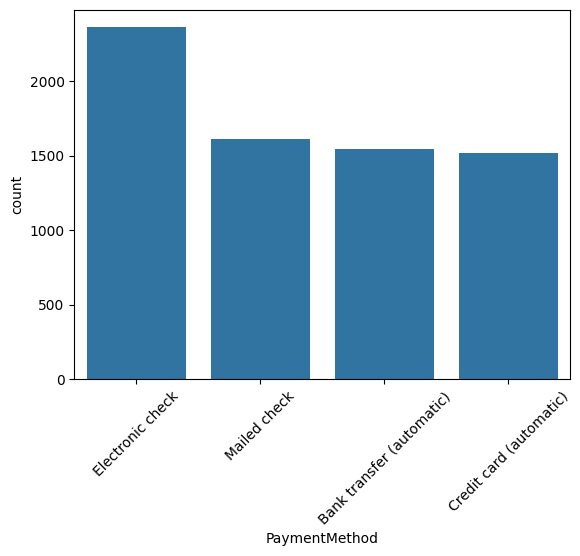

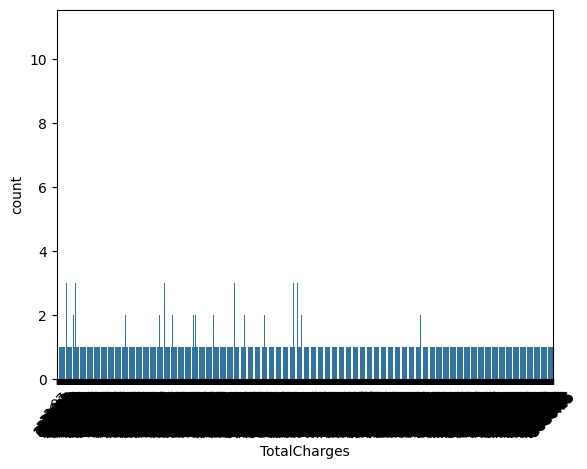

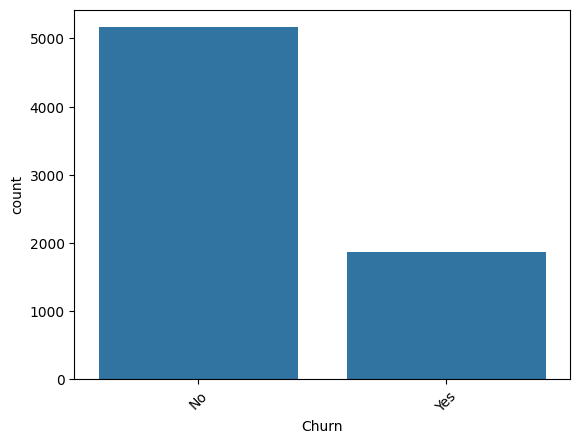

In [ ]:
for col in df.select_dtypes(include=np.number):
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

for col in df.select_dtypes(include='object'):
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.show()



In [ ]:
# 7. Bivariate Analysis
sns.countplot(x='Churn', data=df)
plt.show()

for col in df.select_dtypes(include='object'):
    if col != 'Churn':
        sns.countplot(x=col, hue='Churn', data=df)
        plt.xticks(rotation=45)
        plt.show()


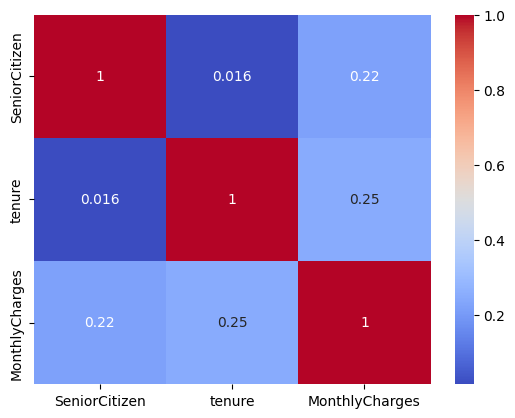

In [ ]:
# 8. Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# 9. Handle Outliers (IQR method)
for col in df.select_dtypes(include=np.number):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

In [ ]:
# 10. Encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [ ]:
# 11. Scaling
scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df)

In [ ]:
# 12. Separate Features & Target
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
# 13. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 14. Handle Imbalance (SMOTE)
sm = SMOTE(random_state=42)
# Convert y_train back to integer type before applying SMOTE
y_train = y_train.astype(int)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [ ]:
# 15. Train Models
models = {
    "Logistic": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier()
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Convert y_test to integer type before calculating metrics
    y_test_int = y_test.astype(int)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_int, y_pred),
        "Precision": precision_score(y_test_int, y_pred),
        "Recall": recall_score(y_test_int, y_pred),
        "F1 Score": f1_score(y_test_int, y_pred)
    })


In [ ]:
# 16. Evaluation Results
results_df = pd.DataFrame(results)
print(results_df)

               Model  Accuracy  Precision    Recall  F1 Score
0           Logistic  0.764856   0.481567  0.800766  0.601439
1                KNN  0.662988   0.366142  0.712644  0.483745
2      Decision Tree  0.726655   0.410029  0.532567  0.463333
3      Random Forest  0.802207   0.553846  0.551724  0.552783
4                SVM  0.755518   0.462810  0.643678  0.538462
5  Gradient Boosting  0.804754   0.547988  0.678161  0.606164


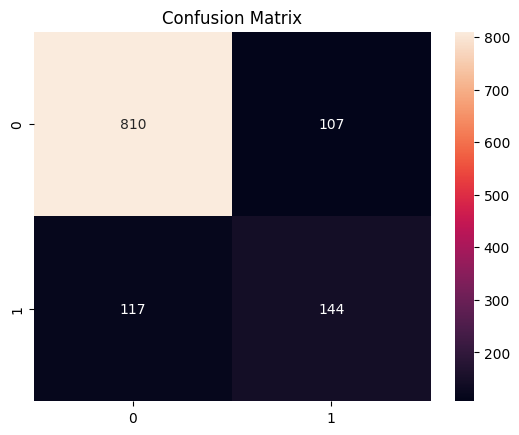

In [ ]:
# Confusion Matrix for best model (example: Random Forest)
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Convert y_test to integer type before calculating the confusion matrix
y_test_int = y_test.astype(int)
cm = confusion_matrix(y_test_int, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# 17. Hyperparameter Tuning (Random Forest example)
params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [ ]:
# 18. Compare Models
print(results_df.sort_values(by='Accuracy', ascending=False))

               Model  Accuracy  Precision    Recall  F1 Score
5  Gradient Boosting  0.804754   0.547988  0.678161  0.606164
3      Random Forest  0.802207   0.553846  0.551724  0.552783
0           Logistic  0.764856   0.481567  0.800766  0.601439
4                SVM  0.755518   0.462810  0.643678  0.538462
2      Decision Tree  0.726655   0.410029  0.532567  0.463333
1                KNN  0.662988   0.366142  0.712644  0.483745


In [ ]:
# 19. Best Model Selection
best = results_df.sort_values(by='Accuracy', ascending=False).iloc[0]
print("Best Model:", best['Model'])

Best Model: Gradient Boosting


In [ ]:
# 20. Final Insights
print("High charges, short tenure, no support → high churn")

High charges, short tenure, no support → high churn


## Insights
● High monthly charges → Higher churn

● Month-to-month contracts → Higher churn

● No tech support → Higher churn

● Short tenure → Higher churn


## Business Recommendations

● Offer long-term contract discounts

● Improve customer support services

● Provide personalized retention offers

● Identify high-risk customers early

● Reduce churn through loyalty programs

